# CN7 OCSVM — 도메인 가설과 오탐 제약 기반 검증

**선택 기준: 개발 OOF 오탐률 ≤ 예산인 후보 중 불량 재현율 최대화. AP는 참고 지표입니다.**

1%·3%·5%는 운영 확정값이 아닌 비교 조건입니다. 세 조건의 모델을 각각 선택하고, test를 보고 조건 하나를 고르지 않습니다.
동률은 FP → fold 재현율 표준편차 → 입력 수 → 후보 순서로 결정합니다. 제약을 만족하며 개발 불량을 탐지한 모델이 없으면 `no_supported_model`로 표시합니다.

기존 AP 기반 분석과 실행 결과는 [보존본](archive/ocsvm_cn7_integrated_ap_20260929.ipynb)에 있습니다. 기존 출력 폴더는 유지하고 새 결과는 `output/ocsvm_cn7_integrated/domain_fpr_20260929/`에 저장합니다.
구현은 [cn7_domain_fpr.py](cn7_domain_fpr.py)에 모아 탐색·보정·최종 추론의 변환을 통일했습니다. 새 커널에서 위부터 실행하세요.

## A. 평가 설계

- 기존 패턴 단위 development/test 분할과 4-fold를 유지합니다. 정상·불량 공존 패턴은 불량 이력 라벨을 유지합니다.
- 각 개발 fold의 **정상 학습 행 중 65%는 모델 적합, 35%는 임계값 보정**에 사용합니다. scaler·파생변수 활성 센서·상수 제거·PCA는 적합 행만 봅니다. 보정 행은 모델 학습에 사용하지 않습니다.
- 보정 정상 점수의 `ceil((n+1)×(1−오탐 예산))`번째 순서통계량을 임계값으로 사용하고 `점수 > 임계값`일 때만 경보합니다. 표본이 부족하면 +∞로 경보를 내지 않습니다. 동점 점수는 분할하지 않습니다.
- 임계값을 고정한 뒤 해당 fold 검증 행의 TP·FP·FN·TN을 측정합니다. **fold별 예측을 합산**하여 재현율·오탐률을 계산하고 원시 점수는 합쳐 임계값을 선택하지 않습니다.
- 4-fold에서 같은 후보를 반복 비교하는 개발 선택입니다. nested CV 또는 독립 성능 추정이 아닙니다. 오탐 제약은 개발 OOF 관측값에 적용되며 모집단·각 fold·test에서 보장되지 않습니다.
- 최종 모델도 개발 정상 행을 동일 비율로 적합/보정 분할합니다. 보정 뒤 전체 정상으로 다시 학습하지 않아 모델과 임계값의 점수 척도를 유지합니다.
- test는 모든 조건의 선택을 저장한 뒤 한 번 평가합니다. 이전 분석에서 이미 관찰한 test이므로 후속 평가이며 독립 검증은 새 자료가 필요합니다. 비라벨 추론은 수행하지 않습니다.


In [1]:
from pathlib import Path
import os, sys, json, platform
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/origin').is_dir())
os.environ['MPLCONFIGDIR'] = str(ROOT/'tmp/matplotlib_cache')
sys.path.insert(0, str(ROOT/'modeling'))
import cn7_domain_fpr as workflow
import numpy as np
import pandas as pd
import sklearn
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
OUT = ROOT/'output/ocsvm_cn7_integrated/domain_fpr_20260929'
OUT.mkdir(parents=True, exist_ok=True)
# 예산과 후보는 test 평가 전에 고정합니다.
BUDGETS = workflow.BUDGETS
print('오탐 비교 조건:', BUDGETS)
print('시나리오당', len(workflow.NU_VALUES)*len(workflow.GAMMA_MULTIPLIERS), '개 설정')
X, y, assignment, dev, test, source_manifest = workflow.load_data(ROOT)
Xdev, ydev = X.loc[dev].copy(), y.loc[dev].copy()
fold_ids = assignment.loc[dev, 'cv_fold'].copy()
print('개발:', len(dev), '위험:', int(ydev.sum()), '| 고정 test:', len(test))
old_root = ROOT/'output/ocsvm_cn7_integrated/expanded_search_20260929'
protected_hashes = {str(p.relative_to(ROOT)): workflow.digest(p) for p in old_root.rglob('*') if p.is_file()}
workflow.write_json(OUT/'run_config.json', {
    'version': workflow.VERSION, 'source_sha256': source_manifest['source_sha256'],
    'split_sha256': workflow.digest(ROOT/'data/processed/cn7/conservative/splits/split_assignments.csv'),
    'implementation_sha256': workflow.digest(ROOT/'modeling/cn7_domain_fpr.py'),
    'python': platform.python_version(), 'sklearn': sklearn.__version__,
    'budgets': list(BUDGETS), 'calibration_fraction': workflow.CALIBRATION_FRACTION,
    'seed': workflow.SEED, 'scenarios': workflow.SCENARIOS})


오탐 비교 조건: (0.01, 0.03, 0.05)
시나리오당 616 개 설정
개발: 484 위험: 11 | 고정 test: 122


## B. 도메인 가설을 먼저 정의한 파생변수

제공 데이터는 컬럼별 표준화 값입니다. 아래 z는 **정상 적합 행 기준으로 다시 표준화한 상대 편차**입니다. 실제 초·bar·℃ 차이, 동력, 유량, 점도, 체적을 복원할 수 없습니다.

문헌은 공정 변수 간 관계를 뒷받침할 뿐, 아래 수식의 CN7 예측력이나 인과 효과를 검증하지 않았습니다. 수식은 명시적인 탐색 가설입니다.
사출압력과 전환의 관계는 [ARBURG 64/2017, p.27](https://www.arburg.com/media/daten/publications/today/Arburg_today64_2017_681763_en_gb.pdf), 가소화·사출 변수 구분은 [Liew 등, Sensors 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9268792/)를 참고했습니다. 센서명은 제공 데이터와 저장소 용어 자료를 참고했습니다. 센서 위치·측정 시간창·실제 단위는 추가 확인이 필요합니다.

| 가설군 | 수식 | 확인하려는 상대 변화 |
|---|---|---|
| 충전·전환 | z(최대 사출압력) − z(전환압력) | 사출과 전환의 상대 변화 불일치 |
| 가소화 | z(최대 RPM) − z(평균 RPM), z(최대 배압) − z(평균 배압) | 최대·평균 상대 변화 불일치 |
| 열 상태 | 활성 배럴 z 평균·표준편차, 금형 z 평균·차이 | 센서들의 공통 이동과 상대 변화 차이 |

최대 7개를 정의하며 두 센서 이상이 실제 변할 때만 생성합니다. 배럴 센서의 상수값을 공간 분포에 포함하지 않습니다. 센서 활성 여부는 적합 행에서만 결정하며 적용 행에서 바꾸지 않습니다.
기존 속도×시간·압력·쿠션 및 계량시간×배압, 사출시간−충전시간은 물리 해석과 측정 정의가 불충분해 이번 후보에서 제외했습니다. 배럴 범위는 표준편차와 유사한 가설의 중복 추가를 줄이기 위해 제외했습니다.

원변수는 기본 유지합니다. `pressure`, `plasticizing`, `thermal`은 원변수+해당 가설군, `domain_all`은 원변수+전체 가설군입니다.
`legacy_without_cycle`은 과거 제외 효과를 확인하는 비교군이며 도메인 필수 삭제가 아닙니다. `group_pca`는 공정군별 PC 최대 2개와 잔차 RMSE를 사용하는 통계적 비교군입니다.


In [2]:
domain_definitions = pd.DataFrame(workflow.DOMAIN_SPEC)
display(domain_definitions[['feature','group','operation','columns','hypothesis','limitation']])
display(pd.DataFrame([{'scenario': key, 'domain_groups': ', '.join(value) or '비교군'}
                      for key, value in workflow.SCENARIOS.items()]))


,feature,group,operation,columns,hypothesis,limitation
0,사출_전환압력_상대편차,pressure,difference,"[Max_Injection_Pressure, Max_Switch_Over_Press...",최대 사출압력과 전환압력이 정상 대비 함께 변하는지 확인,서로 다른 시점의 요약값이며 실제 압력 강하가 아님
1,스크루RPM_상대편차,plasticizing,difference,"[Max_Screw_RPM, Average_Screw_RPM]",가소화 회전수의 최대·평균 상대 변화 불일치,실제 RPM 폭이나 시간적 변동성으로 해석할 수 없음
2,배압_상대편차,plasticizing,difference,"[Max_Back_Pressure, Average_Back_Pressure]",가소화 배압의 최대·평균 상대 변화 불일치,실제 배압 차이 또는 불량 인과 효과가 아님
3,배럴_상대수준평균,thermal,mean,"[Barrel_Temperature_1, Barrel_Temperature_2, B...",활성 배럴 센서의 정상 대비 공통 온도 이동,평균 섭씨 온도 아님; 센서 위치·목표 온도는 미확인
4,배럴_상대편차표준편차,thermal,std,"[Barrel_Temperature_1, Barrel_Temperature_2, B...",활성 배럴 센서의 정상 대비 변화가 서로 다른 정도,물리적 온도 균일도·공간 구배 아님
5,금형_상대수준평균,thermal,mean,"[Mold_Temperature_3, Mold_Temperature_4]",금형 센서의 정상 대비 공통 온도 이동,센서가 상·하형인지 미확인; 평균 섭씨 온도 아님
6,금형온도_상대편차,thermal,difference,"[Mold_Temperature_3, Mold_Temperature_4]",금형 두 센서의 정상 대비 상대 변화 불일치,실제 온도차·냉각 효율 아님


,scenario,domain_groups
0,raw,비교군
1,legacy_without_cycle,비교군
2,pressure,pressure
3,plasticizing,plasticizing
4,thermal,thermal
5,domain_all,"pressure, plasticizing, thermal"
6,group_pca,비교군


## C. 모든 후보를 동일 선택 기준으로 탐색

7개 시나리오 × nu 28개 × gamma 배수 22개 × 4-fold = **17,248회 모델 적합**입니다. 각 모델에서 세 오탐 예산을 평가하므로 예산 때문에 모델을 세 번 학습하지 않습니다.
실제 gamma는 배수를 해당 fold의 입력 수로 나눕니다. 파생변수 추가는 RBF 거리 가중치도 바꾸므로 성능 변화가 새로운 정보의 추가만을 의미하지 않습니다.
AP·ROC-AUC는 fold 참고 지표로만 저장합니다. threshold·파라미터·변수·시나리오·중요도 선택에 사용하지 않습니다.


In [3]:
search, fold_search, selected, plans = workflow.search_development(Xdev, ydev, fold_ids, OUT)
expected = len(workflow.SCENARIOS)*len(workflow.NU_VALUES)*len(workflow.GAMMA_MULTIPLIERS)
assert len(search) == expected*len(BUDGETS)
assert len(fold_search) == expected*len(BUDGETS)*4
assert all(not (set(p['fit']) | set(p['cal']) | set(p['valid'])) & set(test) for p in plans)
print('후보 설정 수:', expected, '| fold 모델 적합 수:', expected*4)
display(pd.DataFrame(selected))


raw: 616개 설정 × 4 folds 완료
legacy_without_cycle: 616개 설정 × 4 folds 완료
pressure: 616개 설정 × 4 folds 완료
plasticizing: 616개 설정 × 4 folds 완료
thermal: 616개 설정 × 4 folds 완료
domain_all: 616개 설정 × 4 folds 완료
group_pca: 616개 설정 × 4 folds 완료
후보 설정 수: 4312 | fold 모델 적합 수: 17248


,candidate_id,scenario,nu,gamma_multiplier,budget,feature_count,TP,FP,FN,TN,recall,FPR,precision,recall_std,worst_fold_recall,max_fold_FPR,mean_AP_reference,mean_ROC_AUC_reference,status
0,627,legacy_without_cycle,0.001,0.173205,0.01,21,4,2,7,471,0.363636,0.004228,0.666667,0.083333,0.333333,0.008475,0.352360,0.685521,selected_for_followup
1,1107,legacy_without_cycle,0.125,0.063599,0.03,21,5,6,6,467,0.454545,0.012685,0.454545,0.159571,0.333333,0.033898,0.323999,0.725104,selected_for_followup
2,1251,pressure,0.001,2.000000,0.05,24,6,16,5,457,0.545455,0.033827,0.272727,0.159571,0.333333,0.075630,0.421671,0.799483,selected_for_followup


## D. 가설군 비교와 선택 근거

각 시나리오에서도 동일한 오탐 제약으로 최적 후보를 구합니다. 상한을 넘는 후보는 제외하며, 불량 탐지 근거가 없으면 별도 상태로 표시합니다. 아래 히트맵의 빈칸은 개발 오탐 제약을 만족하지 못한 설정입니다.


,budget,scenario,status,TP,FP,FN,TN,recall,FPR,recall_std,max_fold_FPR,feature_count,nu,gamma_multiplier
0,0.01,raw,selected_for_followup,4.0,4.0,7.0,469.0,0.363636,0.008457,0.083333,0.025210,23.0,0.030,0.020000
1,0.03,raw,selected_for_followup,5.0,9.0,6.0,464.0,0.454545,0.019027,0.159571,0.042017,23.0,0.150,0.081701
2,0.05,raw,selected_for_followup,5.0,16.0,6.0,457.0,0.454545,0.033827,0.159571,0.092437,23.0,0.001,2.000000
3,0.01,legacy_without_cycle,selected_for_followup,4.0,2.0,7.0,471.0,0.363636,0.004228,0.083333,0.008475,21.0,0.001,0.173205
4,0.03,legacy_without_cycle,selected_for_followup,5.0,6.0,6.0,467.0,0.454545,0.012685,0.159571,0.033898,21.0,0.125,0.063599
5,0.05,legacy_without_cycle,selected_for_followup,5.0,16.0,6.0,457.0,0.454545,0.033827,0.159571,0.084034,21.0,0.250,2.000000
6,0.01,pressure,selected_for_followup,4.0,4.0,7.0,469.0,0.363636,0.008457,0.083333,0.025210,24.0,0.060,0.063599
7,0.03,pressure,selected_for_followup,5.0,11.0,6.0,462.0,0.454545,0.023256,0.159571,0.067227,24.0,0.001,2.000000
8,0.05,pressure,selected_for_followup,6.0,16.0,5.0,457.0,0.545455,0.033827,0.159571,0.075630,24.0,0.001,2.000000
9,0.01,plasticizing,selected_for_followup,4.0,4.0,7.0,469.0,0.363636,0.008457,0.083333,0.025210,25.0,0.001,0.134829


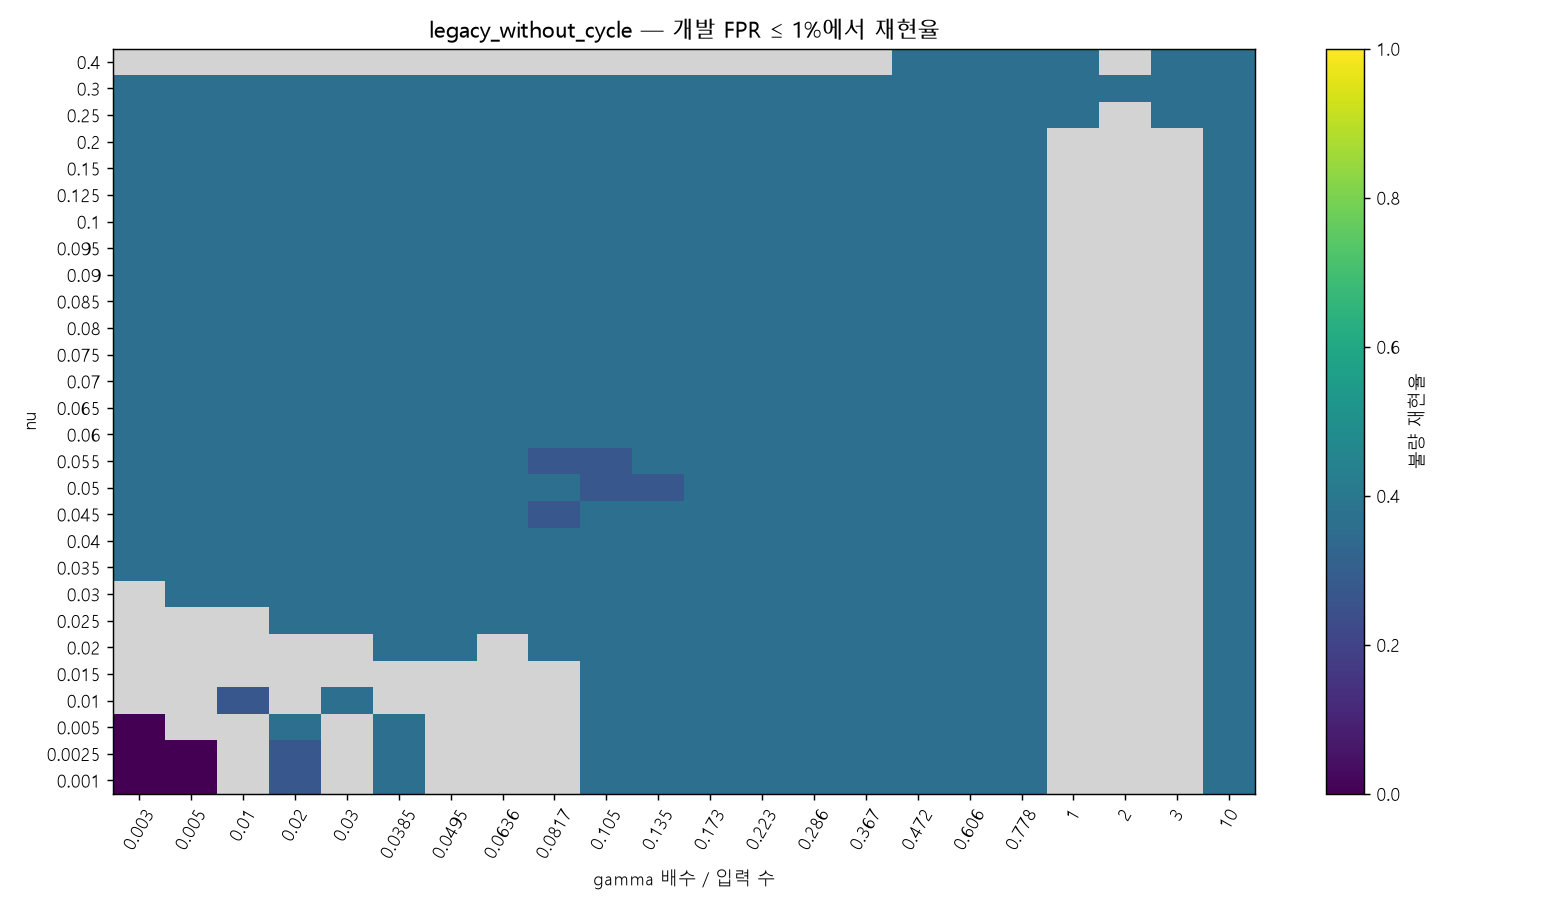

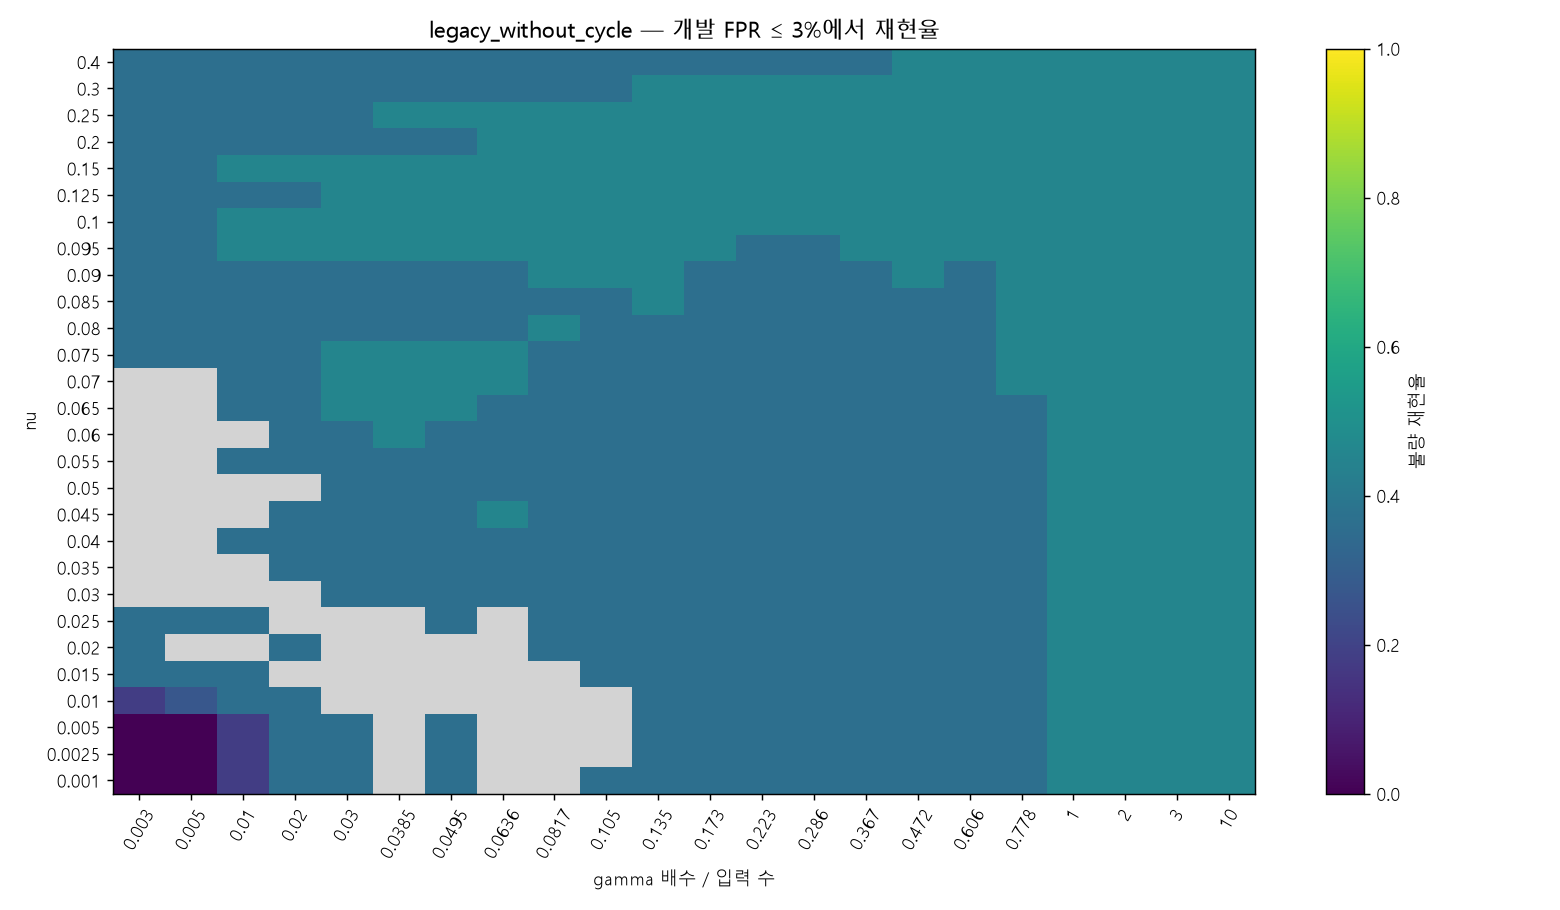

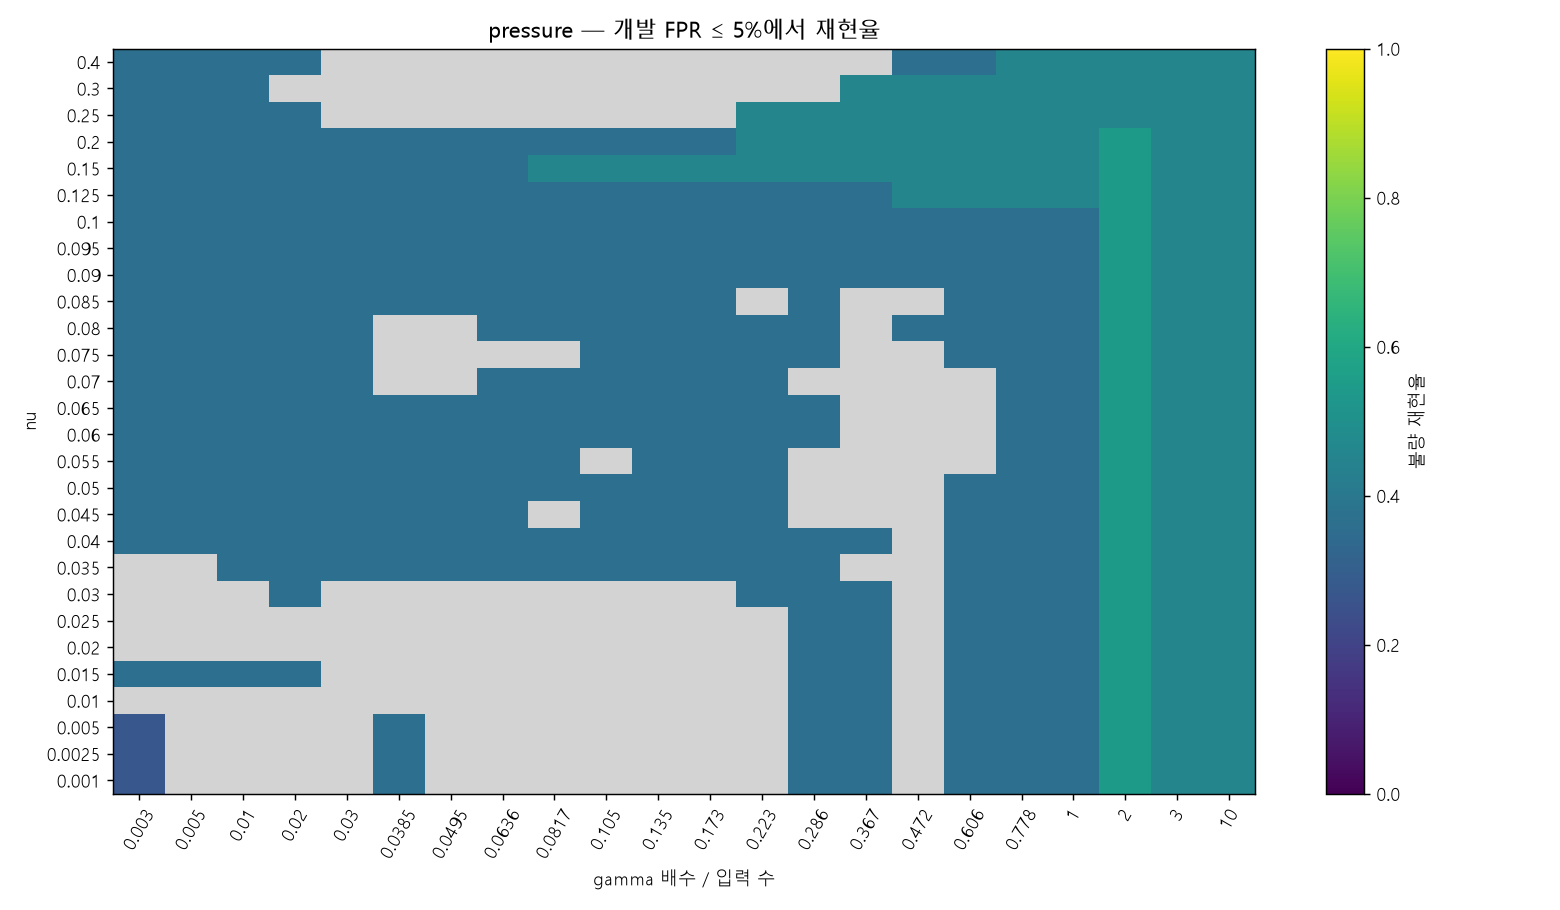

In [4]:
scenario_choices = []
for scenario, part in search.groupby('scenario', sort=False):
    for choice in workflow.select_candidates(part):
        scenario_choices.append({**choice, 'scenario': scenario})
scenario_comparison = pd.DataFrame(scenario_choices)
scenario_comparison.to_csv(OUT/'scenario_comparison.csv', index=False)
display(scenario_comparison.reindex(columns=['budget','scenario','status','TP','FP','FN','TN',
    'recall','FPR','recall_std','max_fold_FPR','feature_count','nu','gamma_multiplier']))
for choice in selected:
    if choice['status'] != 'selected_for_followup':
        print(f"FPR {choice['budget']:.0%}: 선택 가능한 탐지 모델 없음")
        continue
    part = search.loc[search.scenario.eq(choice['scenario']) & search.budget.eq(choice['budget'])].copy()
    part['constrained_recall'] = part.recall.where(part.FPR.le(choice['budget']+1e-12))
    matrix = part.pivot(index='nu', columns='gamma_multiplier', values='constrained_recall')
    fig, ax = plt.subplots(figsize=(12,7))
    cmap = plt.get_cmap('viridis').copy(); cmap.set_bad('lightgray')
    im = ax.imshow(matrix.to_numpy(), origin='lower', aspect='auto', vmin=0, vmax=1, cmap=cmap)
    ax.set_xticks(range(len(matrix.columns)), [f'{v:.3g}' for v in matrix.columns], rotation=60)
    ax.set_yticks(range(len(matrix.index)), [f'{v:.4g}' for v in matrix.index])
    ax.set(xlabel='gamma 배수 / 입력 수', ylabel='nu',
           title=f"{choice['scenario']} — 개발 FPR ≤ {choice['budget']:.0%}에서 재현율")
    fig.colorbar(im, ax=ax, label='불량 재현율'); fig.tight_layout()
    path = OUT/f"recall_heatmap_{int(choice['budget']*100):02d}.png"
    fig.savefig(path, dpi=130); plt.close(fig); display(Image(filename=str(path)))


## E. 개발 OOF 예측과 공정군 중요도 진단

검증 원변수에서 같은 공정군을 같은 순서로 섞은 뒤 파생변수를 다시 계산합니다. 변환된 파생 열만 섞어 원변수와의 수식 관계를 깨뜨리는 기존 방식을 교체했습니다.
이미 보정한 임계값을 고정하고 **재현율 감소와 오탐률 증가를 함께** 기록합니다. 공정군 사이 상관관계는 여전히 깨지므로 인과 설명으로 해석하지 않습니다.
20회 반복은 진단용이며 중요도로 변수를 자동 삭제하거나 새 후보를 만들지 않습니다. AP 중요도 및 같은 fold를 이용한 중요도 기반 재선택 루프는 제거했습니다.


In [5]:
oof_predictions, importance = workflow.development_diagnostics(Xdev, ydev, plans, selected, OUT)
if not importance.empty:
    importance_summary = importance.groupby(['budget','scenario','group'], as_index=False).agg(
        mean_recall_drop=('recall_drop','mean'), mean_FPR_increase=('FPR_increase','mean'))
    importance_summary.to_csv(OUT/'group_importance_summary.csv', index=False)
    display(importance_summary)
for choice in selected:
    if choice['status'] == 'selected_for_followup':
        p = oof_predictions.loc[oof_predictions.budget.eq(choice['budget'])]
        assert len(p) == len(dev) and p.pattern_row.is_unique
        observed = workflow.classification_metrics(p.y_true, p.y_pred)
        assert all(observed[k] == choice[k] for k in ['TP','FP','FN','TN'])
        assert observed['FPR'] <= choice['budget']+1e-12
selection_sha = workflow.digest(OUT/'selection_manifest.json')
print('선택 확정 해시:', selection_sha)


선택 확정 해시: 88b3f365cf2fcf7fc056d4595b60a1273d5e96363eca43cb8ef70abe0bc61383


,budget,scenario,group,mean_recall_drop,mean_FPR_increase
0,0.01,legacy_without_cycle,계량과 가소화,0.000000,0.007388
1,0.01,legacy_without_cycle,금형 온도,0.000000,0.001795
2,0.01,legacy_without_cycle,실린더와 호퍼 온도,0.114583,0.007493
3,0.01,legacy_without_cycle,충전과 전환,0.335417,0.019951
4,0.01,legacy_without_cycle,형체와 전체 주기,0.000000,0.000000
5,0.03,legacy_without_cycle,계량과 가소화,0.062500,0.008140
6,0.03,legacy_without_cycle,금형 온도,0.033333,0.004544
7,0.03,legacy_without_cycle,실린더와 호퍼 온도,0.164583,0.009606
8,0.03,legacy_without_cycle,충전과 전환,0.337500,0.020697
9,0.03,legacy_without_cycle,형체와 전체 주기,0.000000,0.000000


## F. 선택 확정 후 최종 적합·보정과 고정 test 후속 평가

선택된 세 조건을 모두 보고합니다. test 결과로 예산·변수·파라미터·임계값을 변경하지 않습니다. 선택 모델이 없으면 경보 없음 기준선만 표시하며 검증된 탐지 모델로 저장하지 않습니다.
저장 모델을 다시 읽어 예측 일치를 확인합니다. 실제 관측 test 오탐률이 예산을 초과하면 그대로 표시합니다.


,budget,status,scenario,TP,FN,FP,TN,recall,FPR,precision,observed_FPR_exceeds_budget,AP_reference
0,0.01,selected_for_followup,legacy_without_cycle,0,3,3,116,0.0,0.025210,0.0,True,0.053682
1,0.03,selected_for_followup,legacy_without_cycle,0,3,6,113,0.0,0.050420,0.0,True,0.069421
2,0.05,selected_for_followup,pressure,0,3,10,109,0.0,0.084034,0.0,True,0.066304


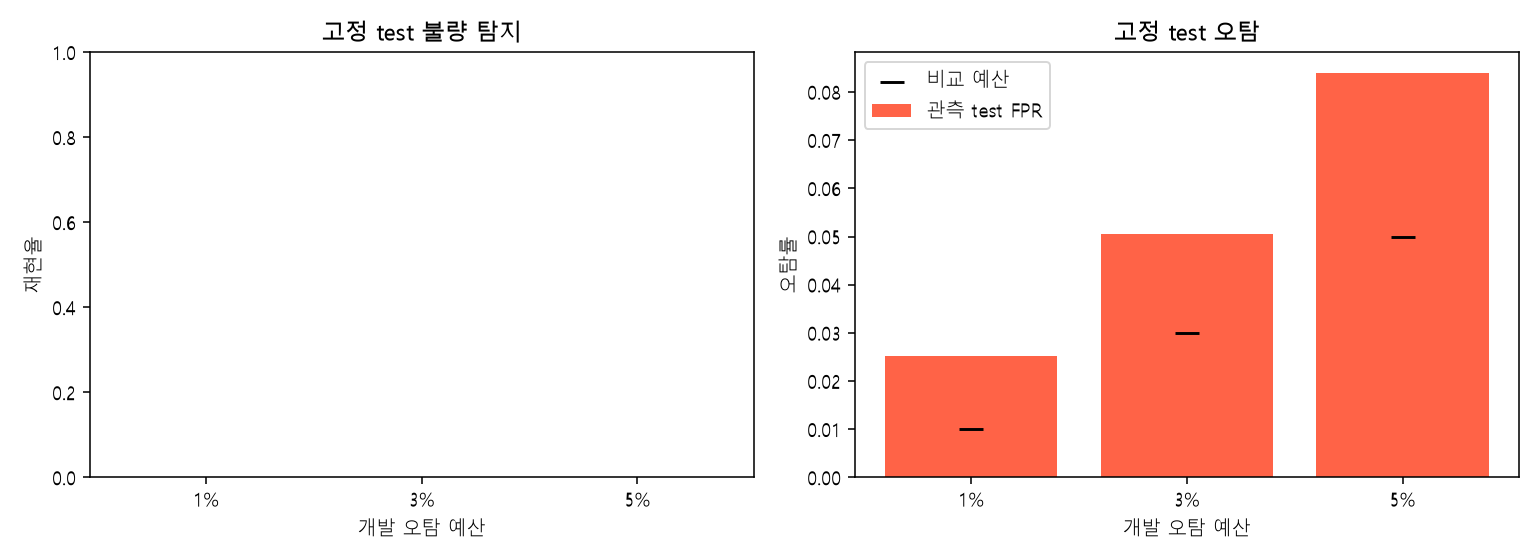

In [6]:
test_results = workflow.evaluate_fixed_test(Xdev, ydev, X.loc[test], y.loc[test], selected, OUT)
assert workflow.digest(OUT/'selection_manifest.json') == selection_sha
display(test_results[['budget','status','scenario','TP','FN','FP','TN','recall','FPR',
                      'precision','observed_FPR_exceeds_budget','AP_reference']])
fig, axes = plt.subplots(1,2, figsize=(11,4))
labels = [f'{b:.0%}' for b in test_results.budget]
axes[0].bar(labels, test_results.recall, color='steelblue')
axes[0].set(xlabel='개발 오탐 예산', ylabel='재현율', ylim=(0,1), title='고정 test 불량 탐지')
axes[1].bar(labels, test_results.FPR, color='tomato', label='관측 test FPR')
axes[1].scatter(labels, test_results.budget, color='black', marker='_', s=160, label='비교 예산')
axes[1].set(xlabel='개발 오탐 예산', ylabel='오탐률', title='고정 test 오탐'); axes[1].legend()
fig.tight_layout(); fig.savefig(OUT/'test_budget_comparison.png', dpi=140); plt.close(fig)
display(Image(filename=str(OUT/'test_budget_comparison.png')))


## G. 실패 유형과 검증 기록

정상·불량 공존 패턴은 동일 입력으로 서로 다른 관측 라벨이 있었던 사례입니다. 이 유형과 불량 전용 유형을 나눠 탐지·누락 수를 보고합니다. 분석 결과에 맞춰 test 임계값을 다시 고르지 않습니다.


In [7]:
metadata = pd.read_csv(ROOT/'data/processed/cn7/conservative/labeled_metadata.csv')
predictions = pd.read_csv(OUT/'test_predictions.csv')
joined = predictions.merge(metadata[['pattern_row','pattern_id','pattern_type']], on='pattern_row', validate='many_to_one')
type_rows = []
for (budget, kind), part in joined.groupby(['budget','pattern_type']):
    type_rows.append({'budget':budget, 'pattern_type':kind, 'rows':len(part),
                      **workflow.classification_metrics(part.y_true, part.y_pred)})
type_results = pd.DataFrame(type_rows)
type_results.to_csv(OUT/'test_pattern_type_metrics.csv', index=False)
display(type_results[['budget','pattern_type','rows','TP','FN','FP','TN']])
assert all(workflow.digest(ROOT/p) == sha for p, sha in protected_hashes.items())
workflow.load_data(ROOT)  # 원자료 및 고정 분할 해시 재검증
assert workflow.digest(OUT/'selection_manifest.json') == selection_sha
summary_lines = ['# CN7 도메인·오탐 제약 검증 결과', '',
    '1%·3%·5%는 비교 조건이며 운영 예산은 확정하지 않았습니다.',
    '선택: 개발 OOF FPR 제약 아래 재현율 최대화. AP는 참고용입니다.', '']
for choice, (_, result) in zip(selected, test_results.iterrows()):
    if choice['status'] == 'selected_for_followup':
        summary_lines.append(f"- {choice['budget']:.0%}: {choice['scenario']}, 개발 TP={int(choice['TP'])}, FP={int(choice['FP'])}, "
            f"재현율={choice['recall']:.3f}, FPR={choice['FPR']:.3f}; "
            f"test TP={result.TP}, FP={result.FP}, FN={result.FN}, TN={result.TN}, FPR={result.FPR:.3f}")
    else:
        summary_lines.append(f"- {choice['budget']:.0%}: 탐지 근거를 갖춘 선택 모델 없음. test는 경보 없음 기준선.")
summary_lines += ['', '개발 선택 성능은 낙관적일 수 있으며 test도 이전에 관찰한 후속 평가입니다.',
                  '모집단 오탐률 보장, 운영 채택, 독립 성능 개선을 주장하지 않습니다.']
summary = '\n'.join(summary_lines)
(OUT/'analysis_summary.md').write_text(summary, encoding='utf-8')
print(summary)
workflow.write_json(OUT/'verification.json', {
    'all_grid_fits_converged': True, 'grid_fits': expected*4,
    'AP_used_for_selection': False, 'test_used_for_selection': False,
    'test_previously_seen': True, 'selection_sha256': selection_sha,
    'fit_calibration_validation_disjoint': True, 'selected_oof_coverage_verified': True,
    'selected_oof_counts_reproduced': True, 'model_reload_predictions_equal': True,
    'old_artifacts_unchanged': True, 'protected_artifact_count': len(protected_hashes),
    'source_and_split_hashes_verified': True,
    'artifact_sha256': {p.name: workflow.digest(p) for p in OUT.iterdir()
                       if p.is_file() and p.name not in ['verification.json','notebook_execution.json']}})


# CN7 도메인·오탐 제약 검증 결과

1%·3%·5%는 비교 조건이며 운영 예산은 확정하지 않았습니다.
선택: 개발 OOF FPR 제약 아래 재현율 최대화. AP는 참고용입니다.

- 1%: legacy_without_cycle, 개발 TP=4, FP=2, 재현율=0.364, FPR=0.004; test TP=0, FP=3, FN=3, TN=116, FPR=0.025
- 3%: legacy_without_cycle, 개발 TP=5, FP=6, 재현율=0.455, FPR=0.013; test TP=0, FP=6, FN=3, TN=113, FPR=0.050
- 5%: pressure, 개발 TP=6, FP=16, 재현율=0.545, FPR=0.034; test TP=0, FP=10, FN=3, TN=109, FPR=0.084

개발 선택 성능은 낙관적일 수 있으며 test도 이전에 관찰한 후속 평가입니다.
모집단 오탐률 보장, 운영 채택, 독립 성능 개선을 주장하지 않습니다.


,budget,pattern_type,rows,TP,FN,FP,TN
0,0.01,conflicting,3,0,3,0,0
1,0.01,normal_only,119,0,0,3,116
2,0.03,conflicting,3,0,3,0,0
3,0.03,normal_only,119,0,0,6,113
4,0.05,conflicting,3,0,3,0,0
5,0.05,normal_only,119,0,0,10,109
